# Cartesian Axis

A one-dimensional Cartesian domain is defined by the interval

$$
x\in[x_{\min},x_{\max}],
$$

with length

$$
L=x_{\max}-x_{\min}.
$$

The continuous coordinate interval is represented numerically by the finite set of coordinate samples

$$
\{x_i\}_{i=0}^{N-1},
$$

where $N$ is the number of samples.

This notebook examines the numerical representation implemented by `CartesianAxis`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from physkit.core.grids import CartesianAxis

## 1. Endpoint-Inclusive Axis

When `endpoint=True`, both the lower and upper bounds are included:

$$
x_0=x_{\min},
\qquad
x_{N-1}=x_{\max}.
$$

The uniform spacing is

$$
d=\frac{L}{N-1}.
$$

In [2]:
closed_axis = CartesianAxis(
    name="x",
    lower=0.0,
    upper=1.0,
    N=5,
    endpoint=True,
)
closed_axis

CartesianAxis(name='x', lower=0.0, upper=1.0, N=5, endpoint=True)

The axis exposes the following numerical data:

- `name`: coordinate-axis label;
- `lower`: lower coordinate bound;
- `upper`: upper coordinate bound;
- `N`: number of coordinate samples;
- `endpoint`: whether the upper bound is included;
- `length`: interval length;
- `delta`: uniform sample spacing;
- `values`: coordinate samples.

At PhysKit revision `0e2b5131a009ef290961065b124c2d28c2ae04e3`, the inspected implementation uses the Python attributes `length` and `delta`. This observation does not establish the future supported public API.

In [ ]:
print(f"name     = {closed_axis.name}")
print(f"lower    = {closed_axis.lower}")
print(f"upper    = {closed_axis.upper}")
print(f"N        = {closed_axis.N}")
print(f"endpoint = {closed_axis.endpoint}")
print(f"L        = {closed_axis.length}")
print(f"delta    = {closed_axis.delta}")
print(f"values   = {closed_axis.values}")

### Verification

For an endpoint-inclusive axis, the implementation must satisfy

$$
x_0=x_{\min},
$$

$$
x_{N-1}=x_{\max},
$$

and

$$
d=\frac{L}{N-1}.
$$

In [ ]:
assert closed_axis.values.shape == (closed_axis.N,)
assert np.isclose(closed_axis.values[0], closed_axis.lower)
assert np.isclose(closed_axis.values[-1], closed_axis.upper)
assert np.isclose(
    closed_axis.delta,
    closed_axis.length / (closed_axis.N - 1),
)

print("Endpoint-inclusive axis checks passed.")

## 2. Endpoint-Excluded Axis

When `endpoint=False`, the lower bound is included but the upper bound is excluded:

$$
x_0=x_{\min},
\qquad
x_{N-1}<x_{\max}.
$$

The uniform spacing is

$$
d=\frac{L}{N}.
$$

This convention is useful for a periodic domain because the points $x_{\min}$ and $x_{\max}$ represent the same location under periodic identification. Excluding $x_{\max}$ avoids storing that location twice.

In [6]:
periodic_axis = CartesianAxis(
    name="x",
    lower=0.0,
    upper=1.0,
    N=5,
    endpoint=False,
)

periodic_axis

CartesianAxis(name='x', lower=0.0, upper=1.0, N=5, endpoint=False)

The mathematical domain continues to have length

$$
L=x_{\max}-x_{\min},
$$

even though $x_{\max}$ is not included in the stored coordinate samples.

In [ ]:
print(f"name     = {periodic_axis.name}")
print(f"lower    = {periodic_axis.lower}")
print(f"upper    = {periodic_axis.upper}")
print(f"N        = {periodic_axis.N}")
print(f"endpoint = {periodic_axis.endpoint}")
print(f"L        = {periodic_axis.length}")
print(f"d        = {periodic_axis.delta}")
print(f"values   = {periodic_axis.values}")

### Verification

For an endpoint-excluded axis, the implementation must satisfy

$$
x_0=x_{\min},
$$

$$
x_{N-1}<x_{\max},
$$

and

$$
\Delta=\frac{L}{N}.
$$

In [ ]:
assert periodic_axis.values.shape == (periodic_axis.N,)
assert np.isclose(periodic_axis.values[0], periodic_axis.lower)
assert periodic_axis.values[-1] < periodic_axis.upper
assert np.isclose(
    periodic_axis.delta,
    periodic_axis.length / periodic_axis.N,
)

print("Endpoint-excluded axis checks passed.")

## 3. Comparison of Sampling Conventions

For the same interval and number of samples, the two endpoint conventions produce different spacings:

$$
\Delta_{\mathrm{closed}}=\frac{L}{N-1},
$$

$$
\Delta_{\mathrm{excluded}}=\frac{L}{N}.
$$

The following visualization shows the locations of the stored coordinate samples.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.scatter(
    closed_axis.values,
    np.ones(closed_axis.N),
    s=80,
    label="endpoint=True",
)

ax.scatter(
    periodic_axis.values,
    np.zeros(periodic_axis.N),
    s=80,
    label="endpoint=False",
)

ax.axvline(
    closed_axis.lower,
    color="black",
    linestyle="--",
    linewidth=1.0,
)

ax.axvline(
    closed_axis.upper,
    color="black",
    linestyle="--",
    linewidth=1.0,
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    [
        "endpoint=False",
        "endpoint=True",
    ]
)

ax.set_xlabel(r"$x$")
ax.set_title("Cartesian-Axis Sampling Conventions")
ax.grid(axis="x", alpha=0.3)

plt.show()

## 4. Resolution and Grid Spacing

For a fixed interval length $L$, increasing $N$ decreases the coordinate spacing.

For endpoint-inclusive sampling,

$$
\Delta_N=\frac{L}{N-1}.
$$

Therefore,

$$
\lim_{N\rightarrow\infty}\Delta_N=0.
$$

The parameter $N$ controls the numerical resolution of the coordinate representation.

In [ ]:
sample_counts = [5, 10, 20, 40, 80]

for N in sample_counts:
    axis = CartesianAxis(
        name="x",
        lower=0.0,
        upper=1.0,
        N=N,
        endpoint=True,
    )

    print(
        f"N = {axis.N:3d}, "
        f"L = {axis.length:.6f}, "
        f"d = {axis.delta:.6f}"
    )

The relationship between $N$ and $d$ can be visualized directly. For endpoint-inclusive sampling,

$$
\Delta=\frac{L}{N-1},
$$

so the spacing decreases approximately as $N^{-1}$ for large $N$.

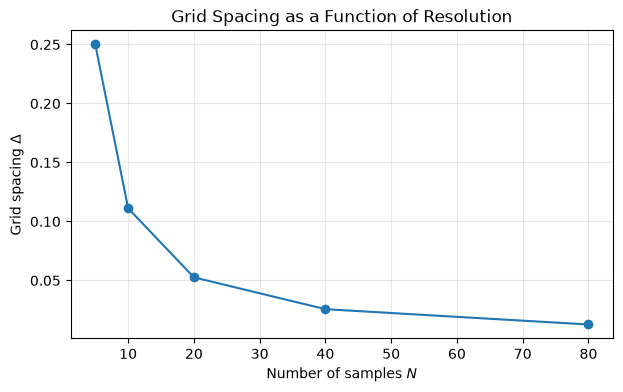

In [15]:
axes = [
    CartesianAxis(
        name="x",
        lower=0.0,
        upper=1.0,
        N=N,
        endpoint=True,
    )
    for N in sample_counts
]

spacings = np.array(
    [axis.delta for axis in axes],
    dtype=np.float64,
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    sample_counts,
    spacings,
    marker="o",
)

ax.set_xlabel(r"Number of samples $N$")
ax.set_ylabel(r"Grid spacing $\Delta$")
ax.set_title("Grid Spacing as a Function of Resolution")
ax.grid(alpha=0.3)

plt.show()

## 5. Sampling a Scalar Field

The axis contains coordinate values:

$$
x_i.
$$

A scalar field $f(x)$ sampled on the axis is represented by

$$
f_i=f(x_i).
$$

The coordinate axis and the sampled field are separate numerical objects:

$$
\{x_i\}_{i=0}^{N-1}
\longrightarrow
\{f_i\}_{i=0}^{N-1}.
$$

In [16]:
axis = CartesianAxis(
    name="x",
    lower=0.0,
    upper=2.0 * np.pi,
    N=128,
    endpoint=False,
)

field = np.sin(axis.values)

print(f"axis shape  = {axis.values.shape}")
print(f"field shape = {field.shape}")

axis shape  = (128,)
field shape = (128,)


For the example

$$
f(x)=\sin(x),
$$

the sampled numerical field is

$$
f_i=\sin(x_i).
$$

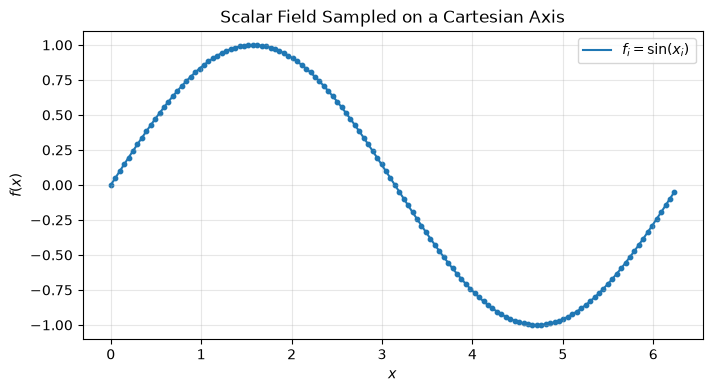

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    axis.values,
    field,
    label=r"$f_i=\sin(x_i)$",
)

ax.scatter(
    axis.values,
    field,
    s=10,
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.set_title("Scalar Field Sampled on a Cartesian Axis")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 6. Periodic Sampling

Consider the periodic field

$$
f(x)=\sin(x)
$$

on the domain

$$
x\in[0,2\pi).
$$

Because

$$
f(0)=f(2\pi),
$$

including both endpoints would duplicate the same physical point. Endpoint-excluded sampling stores one complete period without this duplication.

In [19]:
periodic_axis = CartesianAxis(
    name="x",
    lower=0.0,
    upper=2.0 * np.pi,
    N=16,
    endpoint=False,
)

periodic_field = np.sin(periodic_axis.values)

print(f"first coordinate = {periodic_axis.values[0]:.6f}")
print(f"last coordinate  = {periodic_axis.values[-1]:.6f}")
print(f"upper bound      = {periodic_axis.upper:.6f}")
print(f"spacing          = {periodic_axis.delta:.6f}")

first coordinate = 0.000000
last coordinate  = 5.890486
upper bound      = 6.283185
spacing          = 0.392699


The periodic successor of the final stored sample is the first sample:

$$
x_{N-1}+\Delta x=x_{\max}\equiv x_{\min}.
$$

Here, $\equiv$ denotes equality under periodic identification.

In [21]:
wrapped_coordinate = (
    periodic_axis.values[-1]
    + periodic_axis.delta
)

assert np.isclose(
    wrapped_coordinate,
    periodic_axis.upper,
)

print(
    "Final sample plus one spacing:",
    wrapped_coordinate,
)

print(
    "Periodic equivalent:",
    periodic_axis.lower,
)

Final sample plus one spacing: 6.283185307179586
Periodic equivalent: 0.0


## 7. Invalid Axis Definitions

A valid Cartesian axis requires:

$$
x_{\max}>x_{\min},
$$

$$
N\geq 2,
$$

and finite coordinate bounds.

Invalid definitions should raise explicit exceptions rather than produce an unusable numerical representation.

In [22]:
invalid_definitions = [
    {
        "description": "Reversed bounds",
        "arguments": {
            "name": "x",
            "lower": 1.0,
            "upper": 0.0,
            "N": 10,
        },
    },
    {
        "description": "Insufficient samples",
        "arguments": {
            "name": "x",
            "lower": 0.0,
            "upper": 1.0,
            "N": 1,
        },
    },
    {
        "description": "Nonfinite lower bound",
        "arguments": {
            "name": "x",
            "lower": -np.inf,
            "upper": 1.0,
            "N": 10,
        },
    },
    {
        "description": "Boolean sample count",
        "arguments": {
            "name": "x",
            "lower": 0.0,
            "upper": 1.0,
            "N": True,
        },
    },
]

for case in invalid_definitions:
    try:
        CartesianAxis(**case["arguments"])
    except (TypeError, ValueError) as error:
        print(
            f"{case['description']}: "
            f"{type(error).__name__}: {error}"
        )

Reversed bounds: ValueError: upper must be greater than lower.
Insufficient samples: ValueError: N must be at least 2.
Nonfinite lower bound: ValueError: lower must be finite.
Boolean sample count: TypeError: N must be an integer.


## 8. Numerical Representation Summary

The continuous Cartesian interval is

$$
\Omega_x=[x_{\min},x_{\max}].
$$

Its discrete coordinate representation is

$$
\mathbf{x}
=
\begin{bmatrix}
x_0 & x_1 & \cdots & x_{N-1}
\end{bmatrix}^{\mathsf T}.
$$

For a uniformly sampled axis,

$$
x_i=x_{\min}+id,
\qquad
i=0,1,\ldots,N-1.
$$

The spacing depends on the endpoint convention:

$$
d=
\begin{cases}
\dfrac{L}{N-1},
&
\text{endpoint included},
\\[8pt]
\dfrac{L}{N},
&
\text{endpoint excluded}.
\end{cases}
$$

`CartesianAxis` therefore defines the coordinate state space on which fields, boundary conditions, discrete operators, and numerical solvers can subsequently be constructed.